### 1. Importar librerías

In [1]:
import numpy as np
import xarray as xr
import wavespectra
from wavespectra import read_swan, read_era5, read_ndbc, read_netcdf, read_wwm
import cmocean
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import plotly.graph_objects as go
import numpy as np
from plotly.subplots import make_subplots
import inspect
from sklearn_extra.cluster import CLARA
from pysofar.sofar import SofarApi
from pysofar.spotter import Spotter
import hdpgpc.GPI_HDP as hdpgp
from hdpgpc.get_data import compute_estimators_LDS
from wavespectra.specdataset import SpecDataset
from wavespectra import specarray
import hdpgpc.GPI
import hdpgpc.GPI_model
from matplotlib import gridspec

import xarray as xr
from itertools import combinations
import numpy as np
import xarray as xr

import importlib
import pickle as plk

import torch

from wavespectra.partition import specpart
from wavespectra.core.utils import (
    set_spec_attributes,
    regrid_spec,
    smooth_spec,
    check_same_coordinates,
    D2R,
    celerity,
    is_overlap,
    waveage,
)

C:\Users\marco\anaconda3\envs\hdpgpc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from hdpgpc.util_plots import print_results
import hdpgpc.util_plots as up

In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
pio.templates.default = 'plotly'
from plotly.offline import plot

In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from plotly.offline import plot

In [5]:
import warnings
warnings.filterwarnings("ignore", message="Can't decode floating point timedelta to 's'")

In [6]:
print("CUDA dispoñible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nome do dispositivo:", torch.cuda.get_device_name(0))
    print("Número de dispositivos:", torch.cuda.device_count())

CUDA dispoñible: True
Nome do dispositivo: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Número de dispositivos: 1


---

### 2. Se cargan los archivos de datos y se combinan

In [6]:
ds = read_ndbc('../data/NDBC/dir2017.nc', directional=True, weight_coeff = True).isel(lat=0, lon=0)
ds.to_netcdf("../data/NDBC/dir2017_dir.nc")

In [4]:
# Espectro de energía
ds_wave = xr.open_dataset("../data/NDBC/dir2017_dir.nc", decode_timedelta=True)

# Datos sobre el vientos
ds_meteo = xr.open_dataset("../data/NDBC/meteo2017.nc", decode_timedelta=True)

# Profundidad de medición
ds_ocean = xr.open_dataset("../data/NDBC/ocean2017.nc", decode_timedelta=True)

# Eliminar las dimensiones lat/lon (sólo hay un punto)
ds_meteo = ds_meteo.squeeze(["latitude", "longitude"])
ds_ocean = ds_ocean.squeeze(["latitude", "longitude"])

# Convertir variables codificadas a NumPy arrays para evitar problemas de interpolación
for ds in [ds_meteo, ds_ocean]:
    for var in ds.data_vars:
        ds[var].data = ds[var].values

# Interpolar viento y profundidad al tiempo del espectro
meteo_interp = ds_meteo.interp(time=ds_wave.time)

# Combinar todo en un nuevo dataset
ds = ds_wave.assign({
    "wspd": meteo_interp["wind_spd"],
    "wdir": meteo_interp["wind_dir"]
})

depth_value = float(ds_ocean["depth"].values[0])

dpt_da = xr.DataArray(
    data=np.full_like(ds.time, depth_value, dtype=np.float32),
    coords={"time": ds.time},
    dims=["time"],
    name="dpt"
)

ds["dpt"] = dpt_da

ds

C:\Users\marco\AppData\Local\Temp\ipykernel_5252\1308160770.py:17: SerializationWarning:

Can't decode floating point timedelta to 's' without precision loss, decoding to 'ms' instead. To silence this warning use time_unit='ms' in call to decoding function.

C:\Users\marco\AppData\Local\Temp\ipykernel_5252\1308160770.py:17: SerializationWarning:

Can't decode floating point timedelta to 's' without precision loss, decoding to 'ns' instead. To silence this warning use time_unit='ns' in call to decoding function.



<xarray.Dataset> Size: 118MB
Dimensions:    (time: 8694, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 70kB 2017-01-01 ... 2017-12-31T23:00:00
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B ...
    lon        float32 4B ...
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 118MB ...
    wspd       (time) float64 70kB 7.9 7.1 7.4 5.4 4.2 ... 11.3 11.3 10.8 10.4
    wdir       (time) float64 70kB 274.0 258.0 270.0 262.0 ... 25.0 20.0 16.0
    dpt        (time) float32 35kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

### 3. Filtrado de olas según la relga de Hamilton para aqullas con alturas en el rango (0.5, 2.5)

In [5]:
data = ds['efth'].to_numpy()
freq = ds['freq'].to_numpy()
dir = ds['dir'].to_numpy()

# Datos no direccionales para hacer el filtrado
ds_n = read_ndbc('../data/NDBC/dir2017.nc', directional=False).isel(lat=0, lon=0)
data_no_direct = ds_n['efth'].to_numpy()

In [6]:
print(data.shape)
print(freq)
num_samples, num_obs_per_sample, num_outputs = data.shape

(8694, 47, 36)
[0.02   0.0325 0.0375 0.0425 0.0475 0.0525 0.0575 0.0625 0.0675 0.0725
 0.0775 0.0825 0.0875 0.0925 0.1    0.11   0.12   0.13   0.14   0.15
 0.16   0.17   0.18   0.19   0.2    0.21   0.22   0.23   0.24   0.25
 0.26   0.27   0.28   0.29   0.3    0.31   0.32   0.33   0.34   0.35
 0.365  0.385  0.405  0.425  0.445  0.465  0.485 ]


Shape of hs: (8694, 1)
How much spectra falls in the range 0.5-3.0 Hs: 7776


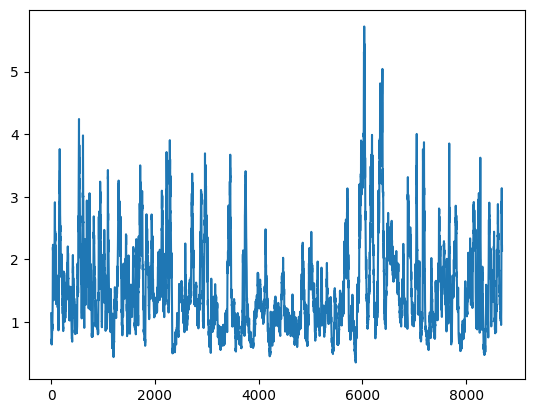

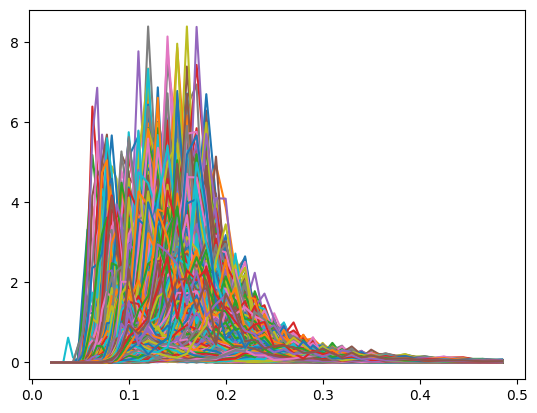

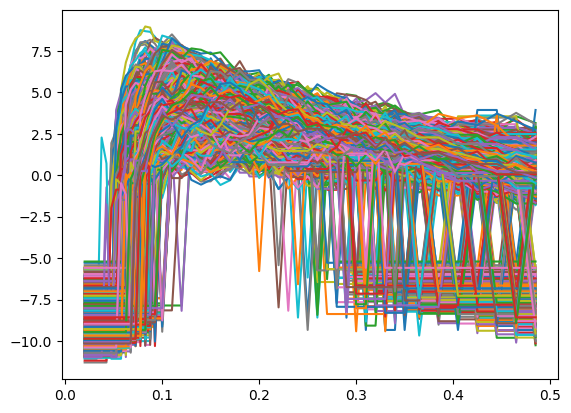

In [7]:
#Here we are going to compute the Heighs and try to filter following Hamiltons rule.
interv = np.repeat(freq[1]-freq[0], num_obs_per_sample)[:, np.newaxis]
hs = 4 * np.sqrt(data_no_direct @ interv)
print("Shape of hs: "+str(hs.shape))
plt.plot(hs)
chosen_indexes = np.where((hs > 0.5) & (hs < 2.5))[0]
#chosen_indexes = np.arange(0, num_samples)
print("How much spectra falls in the range 0.5-3.0 Hs: " + str(chosen_indexes.shape[0]))
plt.show()
plt.plot(freq, data_no_direct[chosen_indexes].T)
plt.show()
lognorm_data = np.log(data_no_direct + 1e-6) - np.mean(np.log(data_no_direct+ 1e-6), axis=1)[:,np.newaxis]
plt.plot(freq, lognorm_data[chosen_indexes].T)
plt.show()

In [8]:
#Select indexes
data = data[chosen_indexes]
print("Shape of the data: ")
print(data.shape)

num_samples, num_obs_per_sample, num_outputs = data.shape

Shape of the data: 
(7776, 47, 36)


### 4. Ajuste de hiperparámetros y ejecución

In [10]:
std, std_dif, bound_sigma, bound_gamma = compute_estimators_LDS(data, n_f=num_samples-1, dim=20)
#Seem like these estimators are so big for this data, let's reduce them
std = std * 0.5
std_dif = std_dif * 0.1
#Using the same one computed for non direcctional.
# std = 0.007834814488887787
# std_dif = 0.0015669628977775575
bound_sigma = (std * 1e-7, std * 1e-5)
bound_gamma = (std_dif * 1e-9, std_dif * 1e-5)



print("Final sigma:", std)
print("Final gamma:", std_dif)
print("Final sigma bound:", bound_sigma)
print("Final gamma bound:", bound_gamma)

Sigma estimated: 1.2893189014597061e-06
Gamma estimated: 1.2893189014597061e-06
Final sigma: 6.446594507298531e-07
Final gamma: 1.2893189014597062e-07
Final sigma bound: (6.44659450729853e-14, 6.446594507298531e-12)
Final gamma bound: (1.2893189014597064e-16, 1.2893189014597064e-12)


In [11]:
M = 2
sigma = [std * 1.0] * M
gamma = [std_dif * 1.0] * M
outputscale_ = 1.0
ini_lengthscale = 1e-2
bound_lengthscale = (1e-7, 5e-1)
samples = [0, num_obs_per_sample]
l, L = samples[0], samples[1]
# x_basis has to have the same dimension structure as data[0], in this case (171,1) but it could be (n_inducing_points, 1).
n_freq = 35
x_basis = np.atleast_2d(freq[0:n_freq]).T
x_train = np.atleast_2d(freq[0:n_freq]).T
print(x_train.shape)
#If x_basis is wanted to be smaller than the observations length, then the inducing points approach can be applied setting this parameter to True.
inducing_points = False
#Choose if warp is going to be applied. (In the most recent version is optimized to work with online inference, but it can be used in offline as an additional step at the end of the clustering).
warp = False
#Warp priors
noise_warp = std * 0.1
bound_noise_warp = (noise_warp * 0.1, noise_warp * 0.2)
#Warp time indexes
x_basis_warp = x_basis

(35, 1)


In [13]:
importlib.reload(hdpgp)
importlib.reload(hdpgpc.GPI)
importlib.reload(hdpgpc.GPI_model)
torch.use_deterministic_algorithms(False)

In [12]:
step = 3
n_blocks = data.shape[0] // step
data_trimmed = data[:n_blocks * step]
data_grouped = data_trimmed.reshape(n_blocks, step, data.shape[1], data.shape[2])
data_avg = data_grouped.mean(axis=1)

In [13]:
data_avg[:, :n_freq, :].shape

(2592, 35, 36)

In [14]:
sw_gp = hdpgp.GPI_HDP(x_basis=x_basis, x_basis_warp=x_basis_warp, n_outputs=36, cuda=False,
                          ini_lengthscale=ini_lengthscale, bound_lengthscale=bound_lengthscale,
                          ini_gamma=gamma, ini_sigma=sigma, ini_outputscale=outputscale_, noise_warp=noise_warp,
                          bound_sigma=bound_sigma, bound_gamma=bound_gamma, bound_noise_warp=bound_noise_warp,
                          verbose=False, max_models=50, inducing_points=inducing_points, reestimate_initial_params=False,
                          n_explore_steps=3, free_deg_MNIV=5, share_gp=True, use_snr=False, reduce_outputs=True, reduce_outputs_ratio=0.3)
#data = data[:100]
#data_exec = data[::3]
#logdata = np.log(data + 1e-6)
#selected_samples = np.arange(0, data.shape[0], 5)
# window_size = 4
# reshaped = data.reshape(data.shape[0] // window_size, window_size, *data.shape[1:])
# windowed_data = reshaped.mean(axis=1)
#num_samples = selected_samples.shape[0]
num_samples = data_avg.shape[0]
x_trains = np.array([x_train] * num_samples)
sw_gp.include_batch(x_trains, data_avg[:,:n_freq,:])

------ HDP Hyperparameters ------
gamma: 0.8
transAlpha: 0.8
startAlpha: 0.8
kappa: 0.0
---------------------------------
Performed reduction of outputs based on variance.
Ratio of reduction: 0.3 Final outputs: [ 3  4  5  6  7  8  9 19 20 21 22]
Group responsability estimated: [2592]
---Kernel estimated---
0.0238**2 * RBF(length_scale=0.0138) + WhiteKernel(noise_level=6.04e-12)
Step 1/3- Trying to divide: 0 with beat 542
Sum resp_temp: [2520   72]
Q_em: -141008.21, Q_lat: -708299.01, Elbo_linear: -211.64, Elbo_LDS: -12866.16
>>> Q_all_loop -------
Sum resp_temp: [2520   72]
Q_em: -141008.21, Q_lat: -708299.01, Elbo_linear: -211.64, Elbo_LDS: -12866.16
Sum resp_temp: [2491  106]
Q_em: -139929.91, Q_lat: -695399.62, Elbo_linear: -205.59, Elbo_LDS: -12954.95
Sum resp_temp: [2491  106]
Q_em: -139929.91, Q_lat: -695399.62, Elbo_linear: -205.59, Elbo_LDS: -12954.95
ELBO_reduction: 13894.95687212015
>>> Q_all_loop -------
Sum resp_temp: [2491  106]
Q_em: -139929.91, Q_lat: -695399.62, Elbo_li

Sum resp_temp: [1598  908  112]
Q_em: -126350.70, Q_lat: -516815.48, Elbo_linear: -781.33, Elbo_LDS: -14177.07
ELBO_reduction: 4392.605766819324
>>> Q_all_loop -------
Sum resp_temp: [1598  908  112]
Q_em: -126350.70, Q_lat: -516815.48, Elbo_linear: -781.33, Elbo_LDS: -14177.07
Sum resp_temp: [1581  918  115]
Q_em: -127114.12, Q_lat: -515249.53, Elbo_linear: -787.53, Elbo_LDS: -14228.20
Sum resp_temp: [1581  918  115]
Q_em: -127114.12, Q_lat: -515249.53, Elbo_linear: -787.53, Elbo_LDS: -14228.20
ELBO_reduction: 745.1921853966778
>>> Q_all_loop -------
Sum resp_temp: [1581  918  115]
Q_em: -127114.12, Q_lat: -515249.53, Elbo_linear: -787.53, Elbo_LDS: -14228.20
Sum resp_temp: [1587  908  121]
Q_em: -127575.96, Q_lat: -515711.18, Elbo_linear: -781.45, Elbo_LDS: -14271.49
Sum resp_temp: [1581  918  115]
Q_em: -127114.12, Q_lat: -515249.53, Elbo_linear: -787.53, Elbo_LDS: -14228.20
ELBO_reduction: 0.0
>>> Prev -------
Sum resp_temp: [2336  261]
Q_em: -137413.16, Q_lat: -657579.05, Elbo_lin

Sum resp_temp: [1297  983  220   77   51]
Q_em: -123742.81, Q_lat: -426854.92, Elbo_linear: -1187.61, Elbo_LDS: -14840.80
First resp: [1297  983  220   77   51]
>>> Q_all_loop -------
Sum resp_temp: [1297  983  220   77   51]
Q_em: -123742.81, Q_lat: -426854.92, Elbo_linear: -1187.61, Elbo_LDS: -14840.80
Sum resp_temp: [1275  977  235   81   59]
Q_em: -123370.35, Q_lat: -428462.20, Elbo_linear: -1191.40, Elbo_LDS: -14896.38
Sum resp_temp: [1297  983  220   77   51]
Q_em: -123742.81, Q_lat: -426854.92, Elbo_linear: -1187.61, Elbo_LDS: -14840.80
ELBO_reduction: 0.0

-------End Lower Bound Iteration 4-------
Sum resp_temp: [1297  983  220   77   51]
Q_em: -123742.81, Q_lat: -426854.92, Elbo_linear: -1170.70, Elbo_LDS: -14840.80
ELBO + Nonlinear: tensor([-566519.7486])

-------Start lower Bound Iteration 5-------
Group responsability estimated: [1297  983  220   77   51]
>>> Prev -------
Sum resp_temp: [1297  983  220   77   51]
Q_em: -123742.81, Q_lat: -426854.92, Elbo_linear: -1170.70, E

>>> Q_all_loop -------
Sum resp_temp: [1035  921  407  164   43   42   40    8]
Q_em: -119675.27, Q_lat: -338570.77, Elbo_linear: -1653.31, Elbo_LDS: -15927.42
Sum resp_temp: [931 776 622 202  62  55  46  10]
Q_em: -113819.37, Q_lat: -335185.37, Elbo_linear: -1701.72, Elbo_LDS: -16519.63
Sum resp_temp: [931 776 622 202  62  55  46  10]
Q_em: -113819.37, Q_lat: -335185.37, Elbo_linear: -1701.72, Elbo_LDS: -16519.63
ELBO_reduction: 8600.661542305956
>>> Q_all_loop -------
Sum resp_temp: [931 776 622 202  62  55  46  10]
Q_em: -113819.37, Q_lat: -335185.37, Elbo_linear: -1701.72, Elbo_LDS: -16519.63
Sum resp_temp: [898 847 424 275  89  67  56  23]
Q_em: -112450.05, Q_lat: -331691.25, Elbo_linear: -1686.70, Elbo_LDS: -16733.80
Sum resp_temp: [898 847 424 275  89  67  56  23]
Q_em: -112450.05, Q_lat: -331691.25, Elbo_linear: -1686.70, Elbo_LDS: -16733.80
ELBO_reduction: 4664.307431270077
>>> Q_all_loop -------
Sum resp_temp: [898 847 424 275  89  67  56  23]
Q_em: -112450.05, Q_lat: -331691

Sum resp_temp: [695 682 383 308 186 173 125  74   2]
Q_em: -110782.03, Q_lat: -304004.22, Elbo_linear: -1818.17, Elbo_LDS: -17414.93
ELBO_reduction: 352.2596730024088
>>> Q_all_loop -------
Sum resp_temp: [695 682 383 308 186 173 125  74   2]
Q_em: -110782.03, Q_lat: -304004.22, Elbo_linear: -1818.17, Elbo_LDS: -17414.93
Sum resp_temp: [691 676 383 308 188 175 125  75   2]
Q_em: -110779.12, Q_lat: -303777.99, Elbo_linear: -1804.41, Elbo_LDS: -17424.47
Sum resp_temp: [691 676 383 308 188 175 125  75   2]
Q_em: -110779.12, Q_lat: -303777.99, Elbo_linear: -1804.41, Elbo_LDS: -17424.47
ELBO_reduction: 233.36089153646026
>>> Q_all_loop -------
Sum resp_temp: [691 676 383 308 188 175 125  75   2]
Q_em: -110779.12, Q_lat: -303777.99, Elbo_linear: -1804.41, Elbo_LDS: -17424.47
Sum resp_temp: [691 674 383 308 189 174 125  75   2]
Q_em: -110779.12, Q_lat: -303777.99, Elbo_linear: -1802.10, Elbo_LDS: -17424.47
Sum resp_temp: [691 674 383 308 189 174 125  75   2]
Q_em: -110779.12, Q_lat: -303777.9

Step 1/3- Trying to divide: 9 with beat 540
Sum resp_temp: [1017  838  390  163  144   36   22   21   16    5    2]
Q_em: -119089.12, Q_lat: -312578.22, Elbo_linear: -2001.18, Elbo_LDS: -16263.68
>>> Q_all_loop -------
Sum resp_temp: [1017  838  390  163  144   36   22   21   16    5    2]
Q_em: -119089.12, Q_lat: -312578.22, Elbo_linear: -2001.18, Elbo_LDS: -16263.68
Sum resp_temp: [848 702 604 214 209  42  28  21  14   5   3]
Q_em: -113061.15, Q_lat: -305952.41, Elbo_linear: -1905.59, Elbo_LDS: -16866.02
Sum resp_temp: [848 702 604 214 209  42  28  21  14   5   3]
Q_em: -113061.15, Q_lat: -305952.41, Elbo_linear: -1905.59, Elbo_LDS: -16866.02
ELBO_reduction: 12147.037627043319
>>> Q_all_loop -------
Sum resp_temp: [848 702 604 214 209  42  28  21  14   5   3]
Q_em: -113061.15, Q_lat: -305952.41, Elbo_linear: -1905.59, Elbo_LDS: -16866.02
Sum resp_temp: [752 728 473 290 289  52  38  21  13   8   5]
Q_em: -111666.90, Q_lat: -301573.96, Elbo_linear: -1903.32, Elbo_LDS: -17106.41
Sum res

Sum resp_temp: [590 555 391 360 296 136 117 104  45  37   6   4]
Q_em: -109176.21, Q_lat: -281645.09, Elbo_linear: -1993.65, Elbo_LDS: -18042.39
ELBO_reduction: 1052.638781617803
>>> Q_all_loop -------
Sum resp_temp: [590 555 391 360 296 136 117 104  45  37   6   4]
Q_em: -109176.21, Q_lat: -281645.09, Elbo_linear: -1993.65, Elbo_LDS: -18042.39
Sum resp_temp: [583 541 383 369 300 138 122 108  46  37   6   4]
Q_em: -109142.48, Q_lat: -281204.51, Elbo_linear: -1990.66, Elbo_LDS: -18065.56
Sum resp_temp: [583 541 383 369 300 138 122 108  46  37   6   4]
Q_em: -109142.48, Q_lat: -281204.51, Elbo_linear: -1990.66, Elbo_LDS: -18065.56
ELBO_reduction: 454.12767408345826
>>> Q_all_loop -------
Sum resp_temp: [583 541 383 369 300 138 122 108  46  37   6   4]
Q_em: -109142.48, Q_lat: -281204.51, Elbo_linear: -1990.66, Elbo_LDS: -18065.56
Sum resp_temp: [579 528 376 369 301 144 129 108  46  38   6   4]
Q_em: -109173.56, Q_lat: -279747.37, Elbo_linear: -1997.78, Elbo_LDS: -18063.93
Sum resp_temp: 

Sum resp_temp: [594 494 423 353 342 140 126  93  45  26   7   2   2]
Q_em: -109515.80, Q_lat: -281177.26, Elbo_linear: -2034.96, Elbo_LDS: -17988.57
ELBO_reduction: 0.0
>>> Prev -------
Sum resp_temp: [580 462 380 372 292 199 137 107  44  38   6   4]
Q_em: -109036.45, Q_lat: -278730.92, Elbo_linear: -1910.04, Elbo_LDS: -18092.10
>>> Post -------
Sum resp_temp: [594 494 423 353 342 140 126  93  45  26   7   2   2]
Q_em: -109515.80, Q_lat: -281177.26, Elbo_linear: -2034.96, Elbo_LDS: -17988.57
Step 2/3- Trying to divide: 0 with beat 2434
Sum resp_temp: [1016  771  351  194  149   53   52   23   21   17    7    4    2]
Q_em: -118373.10, Q_lat: -296890.35, Elbo_linear: -2116.68, Elbo_LDS: -16613.44
>>> Q_all_loop -------
Sum resp_temp: [1016  771  351  194  149   53   52   23   21   17    7    4    2]
Q_em: -118373.10, Q_lat: -296890.35, Elbo_linear: -2116.68, Elbo_LDS: -16613.44
Sum resp_temp: [724 653 559 306 173 143  54  29  22  17   7   4   3]
Q_em: -112535.99, Q_lat: -279477.43, Elbo_

Step 1/3- Trying to divide: 10 with beat 539
Sum resp_temp: [891 764 257 191 171 142 111  54  31  18  18  13   4   2   1]
Q_em: -117302.43, Q_lat: -264573.61, Elbo_linear: -2296.94, Elbo_LDS: -17114.71
>>> Q_all_loop -------
Sum resp_temp: [891 764 257 191 171 142 111  54  31  18  18  13   4   2   1]
Q_em: -117302.43, Q_lat: -264573.61, Elbo_linear: -2296.94, Elbo_LDS: -17114.71
Sum resp_temp: [744 488 460 288 208 200 114  68  33  29  21  13   4   2   1]
Q_em: -110879.21, Q_lat: -256261.78, Elbo_linear: -2235.51, Elbo_LDS: -17797.02
Sum resp_temp: [744 488 460 288 208 200 114  68  33  29  21  13   4   2   1]
Q_em: -110879.21, Q_lat: -256261.78, Elbo_linear: -2235.51, Elbo_LDS: -17797.02
ELBO_reduction: 14114.160298869247
>>> Q_all_loop -------
Sum resp_temp: [744 488 460 288 208 200 114  68  33  29  21  13   4   2   1]
Q_em: -110879.21, Q_lat: -256261.78, Elbo_linear: -2235.51, Elbo_LDS: -17797.02
Sum resp_temp: [623 507 389 337 254 229 115 104  37  35  20  13   4   2   1]
Q_em: -10923

### 5. Gráficas y resultados

In [16]:
import func_plot
from func_plot import plot_cluster_spectrum_and_timeline

In [ ]:
n = ds_subset.dims['time']
labels = np.full(n, fill_value=-1)

for cluster_id, gp in enumerate(sw_gp.gpmodels[0]):
    labels[gp.indexes] = cluster_id
    
ds_subset['cluster_label'] = (('time',), labels)

In [ ]:
ds_subset.to_netcdf('./ds_cluster_14.nc')

---

In [44]:
# Carga de clustering ya ejecutado
ds_subset = xr.open_dataset("./ds_cluster_14.nc", decode_timedelta=True)
labels = np.unique(ds_subset.cluster_label.values)

In [10]:
# Creación de df de medias
cluster_means = []
cluster_labels = []

for c in np.unique(labels):
    ds_cluster = ds_subset.sel(time=ds_subset.cluster_label == c)

    if ds_cluster.time.size == 0:
        continue

    mean_efth = ds_cluster.efth.mean(dim='time') 
    mean_efth = mean_efth.expand_dims(time=[0])
    cluster_means.append(mean_efth)
    cluster_labels.append(int(c))

efth_cluster_means = xr.concat(cluster_means, dim='time')

ds_cluster_means = xr.Dataset({
    'efth': efth_cluster_means,
    'freq': ds.freq,
    'dir': ds.dir,
})

ds_cluster_means = ds_cluster_means.assign_coords(
    cluster=('time', cluster_labels)
)

ds_cluster_means = ds_cluster_means.swap_dims({'time': 'cluster'})

ds_cluster_means.efth.attrs = ds.efth.attrs
ds_cluster_means.freq.attrs = ds.freq.attrs
ds_cluster_means.dir.attrs = ds.dir.attrs

In [11]:
df = pd.DataFrame({
    'time': pd.to_datetime(ds_subset.time.values),
    'cluster': ds_subset.cluster_label.values
})


df['day'] = df['time'].dt.dayofyear
df['month'] = df['time'].dt.month
df['date'] = df['time'].dt.date

In [12]:
efth_ordered = ds_cluster_means['efth'].transpose('cluster', 'dir', 'freq')
n_clusters = len(labels)

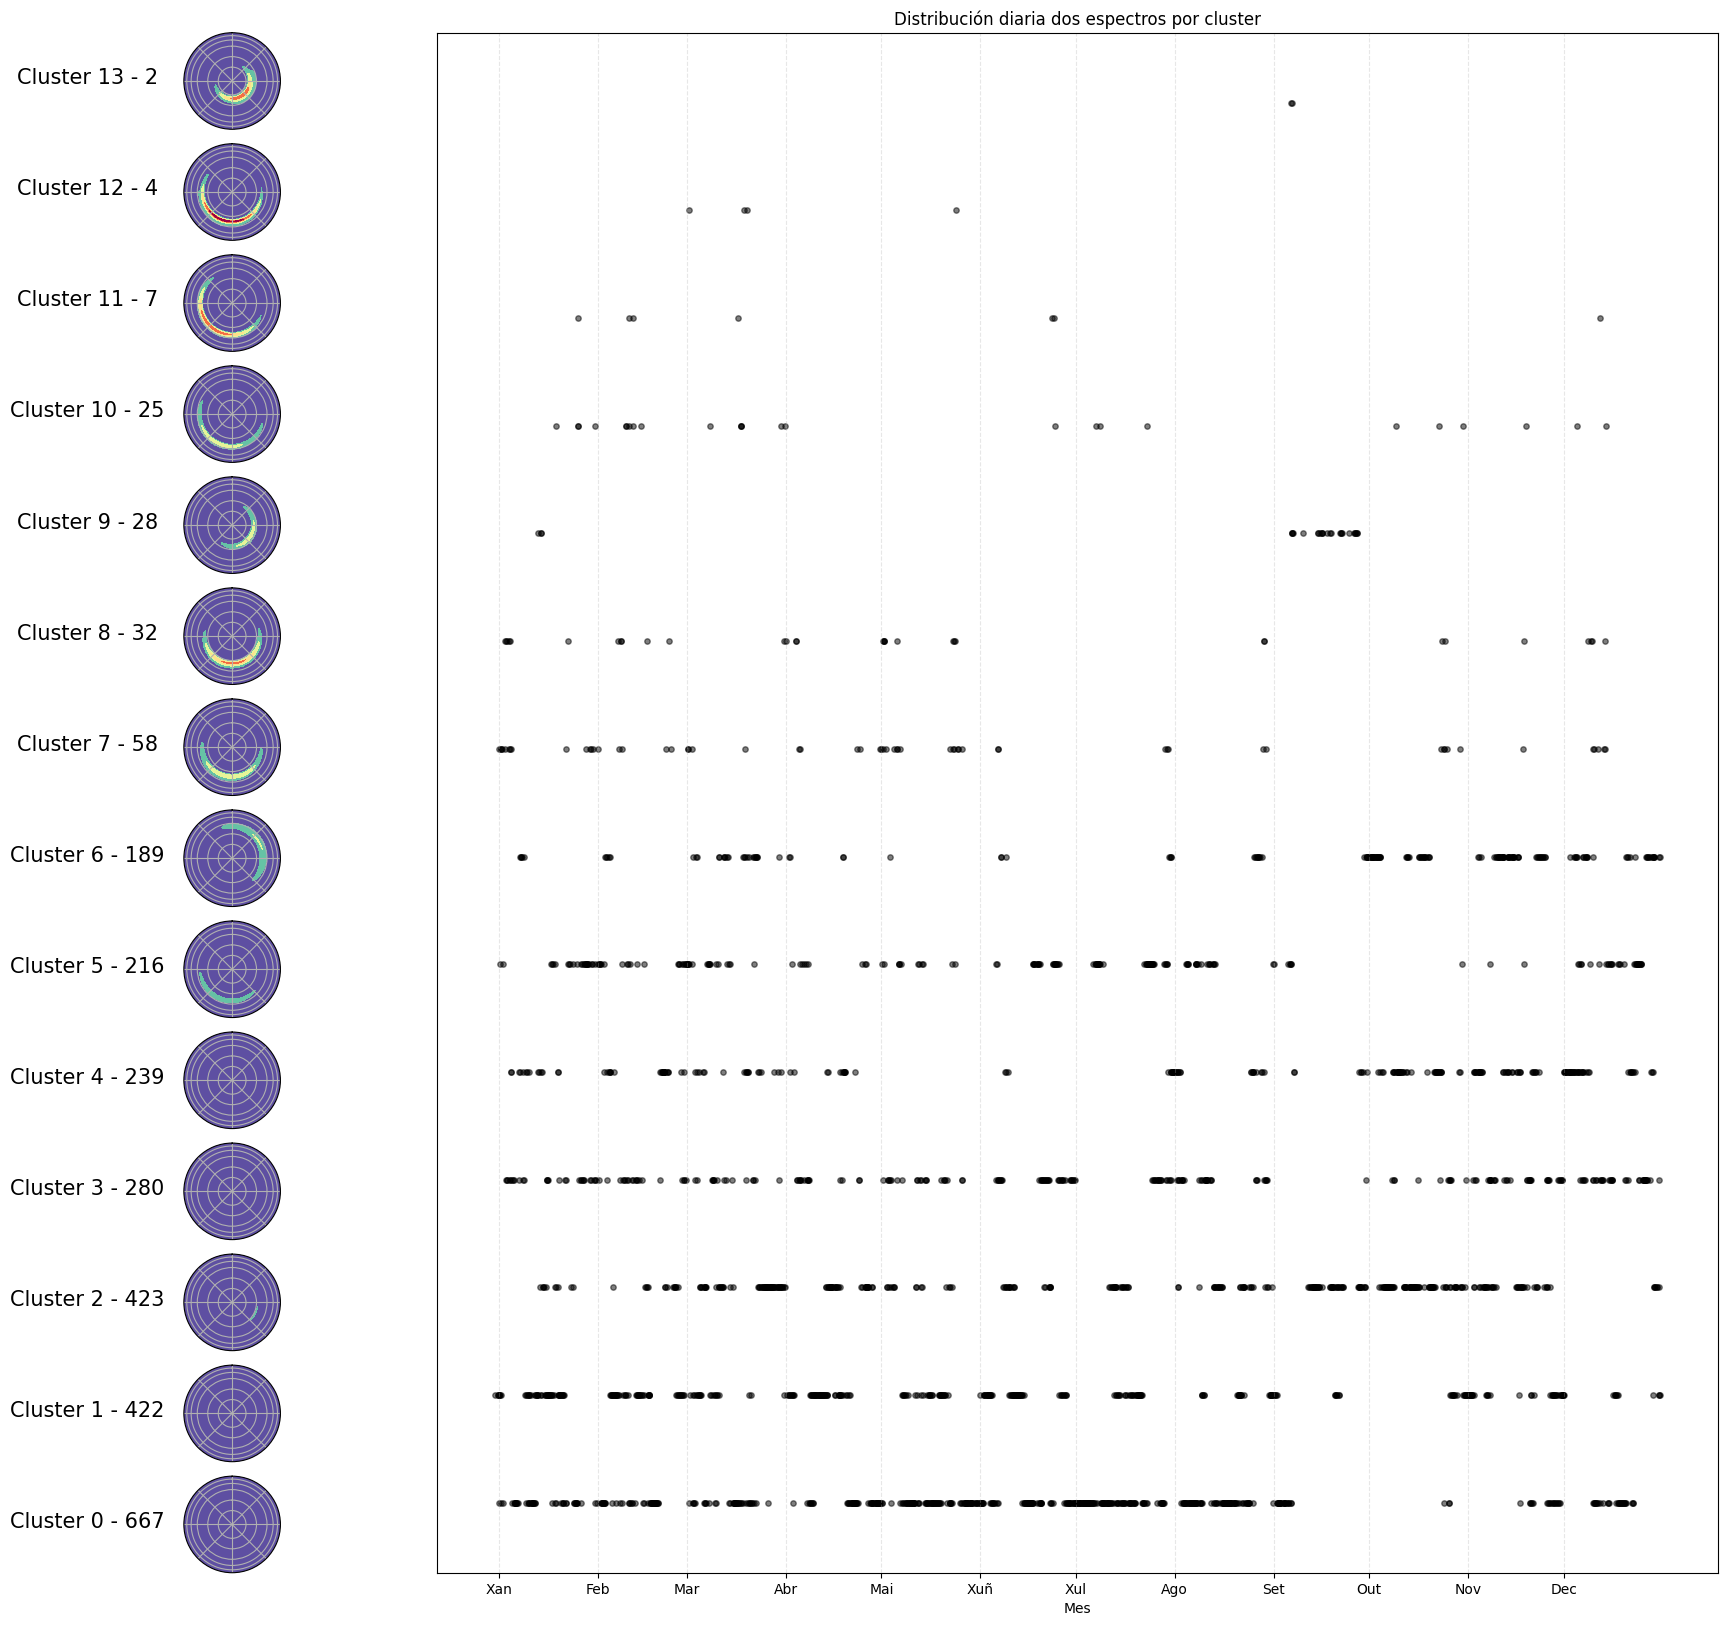

In [18]:
importlib.reload(func_plot)
func_plot.plot_cluster_spectrum_and_timeline(df, efth_ordered, n_clusters, norm=False)

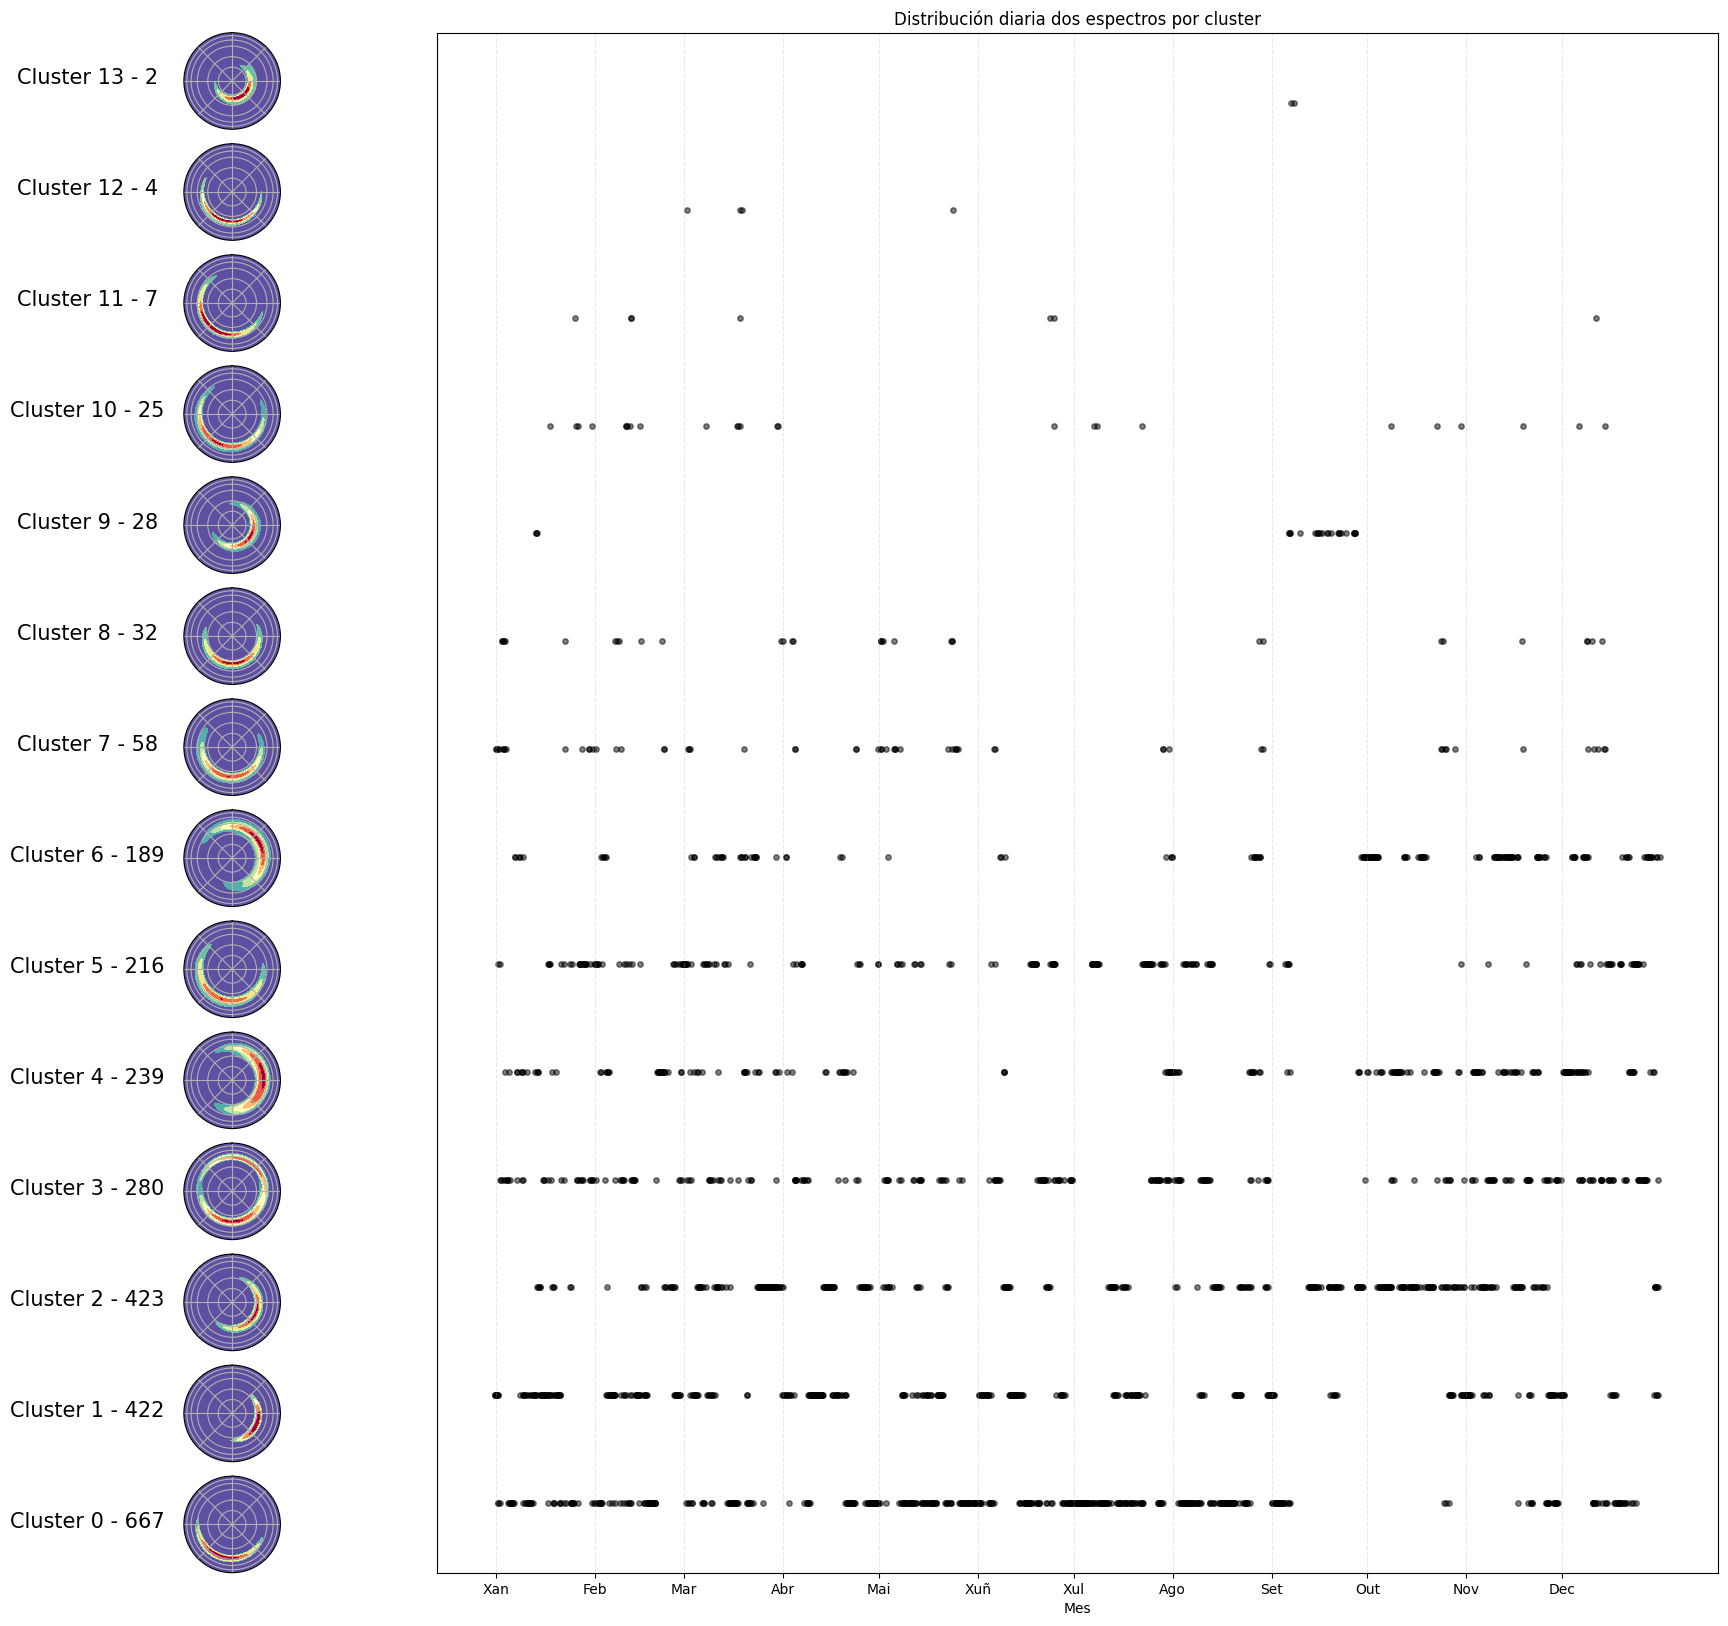

In [17]:
importlib.reload(func_plot)
func_plot.plot_cluster_spectrum_and_timeline(df, efth_ordered, n_clusters, norm=False)

In [15]:
ds_filtered = ds.isel(time=chosen_indexes)
ds_subset = ds_filtered[['efth']].coarsen(time=3, boundary='trim').mean()

In [67]:
from hdpgpc.util_plots import print_results
import hdpgpc.util_plots as up

In [16]:
ds_n = read_ndbc('../data/NDBC/dir2017.nc', directional=False).isel(lat=0, lon=0)
ds_filtered = ds_n.isel(time=chosen_indexes)

data_no_direct = ds_filtered[['efth']].coarsen(time=3, boundary='trim').mean()
data_no_direct = data_no_direct['efth'].to_numpy()

windowed_data_no_direct = data_no_direct
max = np.max(windowed_data_no_direct)
num_clusters = n_clusters

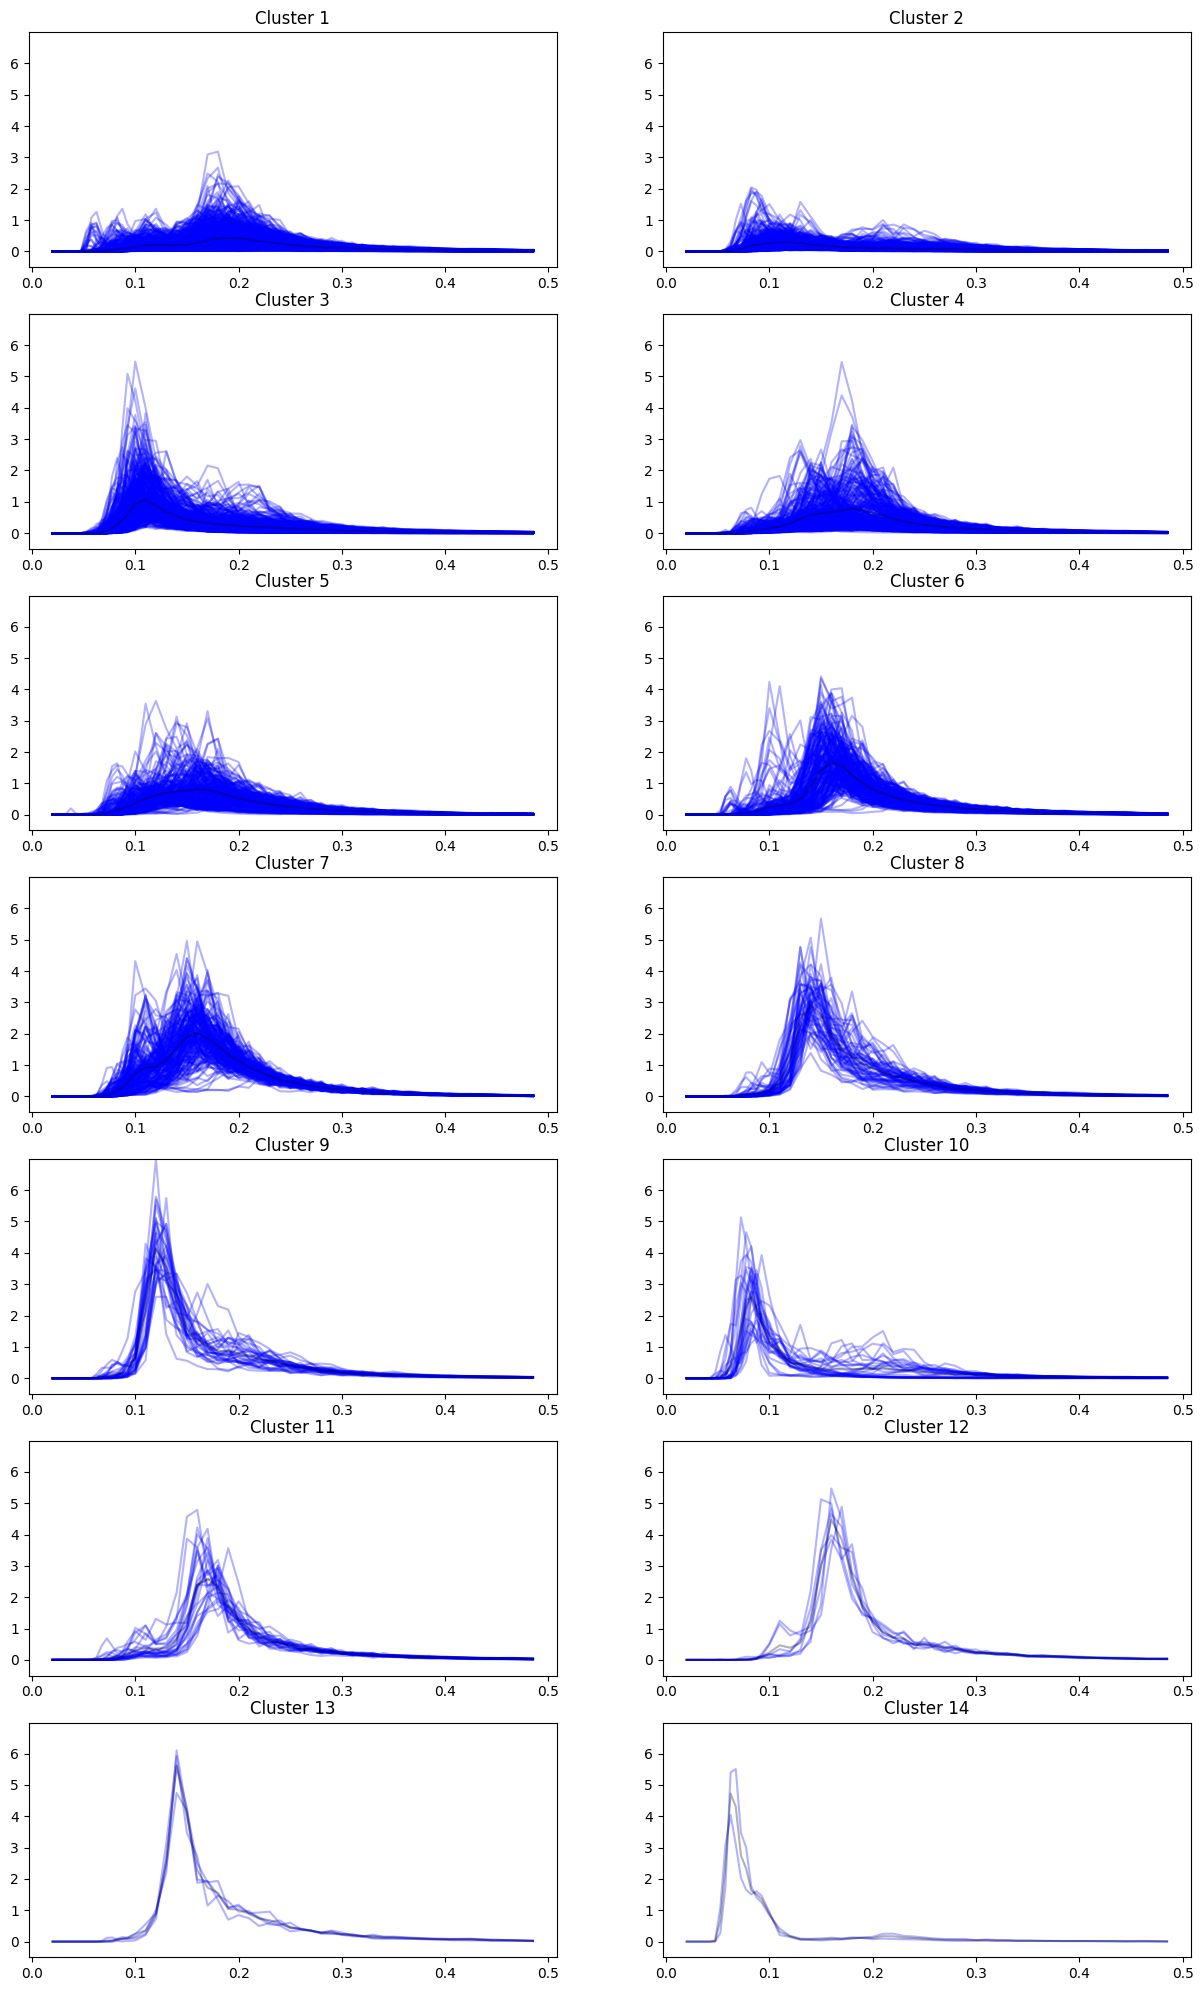

In [23]:
cols = min(2, num_clusters)
rows = (num_clusters // cols) + (num_clusters % cols > 0)
fig, ax = plt.subplots(rows, cols, figsize=(15,25))
for i in range(n_clusters):
    row, col = divmod(i, cols)
    ax[row,col].set_title("Cluster "+str(i+1))
    indices = df[df['cluster'] == i].index
    for j in indices:
        ax[row,col].plot(freq, windowed_data_no_direct[j], 'b', alpha=0.3)
    ax[row,col].plot(freq, np.mean(windowed_data_no_direct[np.array(indices)], axis=0), 'k', alpha=0.3)
    ax[row,col].set_ylim(-0.5, max)

In [50]:
import numpy as np

def classify_partition_portilla(part, freq, dir, wspd, wdir, g=9.81):
    if part.sum() == 0:
        return "null"

    ipeak = np.unravel_index(np.argmax(part, axis=None), part.shape)
    f_peak = freq[ipeak[0]]
    theta_peak = dir[ipeak[1]]
    cp = g / (2 * np.pi * f_peak)
    Ueff = wspd * np.cos(np.radians(theta_peak - wdir))
    waveage = Ueff / cp
    
    if Ueff <= 0:
        return "swell"
    
    beta_min = cp / Ueff
    
    print(beta_min)

    if beta_min <= 1.3:
        return "wind sea"
    elif beta_min <= 2.0:
        return "old wind sea"
    else:
        return "swell"

In [51]:
def hs_func(spec, freq, dir):
    df = np.diff(freq).mean()
    dtheta = np.deg2rad(np.diff(dir).mean())
    m0 = np.sum(spec) * df * dtheta
    return 4 * np.sqrt(m0)


In [52]:
def get_partition_centroid(part, freq, dir):
    energy = part.sum()
    if energy == 0:
        return 0.0, 0.0
    fx = np.sum(part * freq[:, None]) / energy
    dx = np.sum(part * dir[None, :]) / energy
    return fx, dx

def find_closest_partition(i, centroids, valid_idxs):
    fi, di = centroids[i]
    min_dist = float("inf")
    closest = None
    for j in valid_idxs:
        if j == i:
            continue
        fj, dj = centroids[j]
        dist = (fi - fj)**2 + (di - dj)**2
        if dist < min_dist:
            min_dist = dist
            closest = j
    return closest

In [53]:
def np_portilla(
    spectrum,
    spectrum_smooth,
    freq,
    dir,
    wspd,
    wdir,
    dpt,
    swells=None,
    max_parts=10,
    ihmax=500,
    threshold_energy=0.02,
    combine_energy=0.05,
    max_filter_iter=1,
    freq_window=3,
    dir_window=3
):
    total_energy = spectrum.sum()
    filtered = spectrum_smooth.copy()

    for _ in range(max_filter_iter):
        watershed_map = specpart.partition(filtered.values.astype(np.float32), ihmax)
        nparts = watershed_map.max()

        parts = []
        centroids = []
        energies = []

        # Paso 1: gardar todas as particións (sen filtrar)
        for ipart in range(nparts):
            part = np.where(watershed_map == ipart + 1, spectrum, 0.0)
            energy = part.sum()
            parts.append(part)
            centroids.append(get_partition_centroid(part, freq, dir))
            energies.append(energy)

        # Paso 2: combinar particións de baixa enerxía (< threshold_energy)
        valid_idxs = list(range(len(parts)))
        for i in valid_idxs[:]:
            if energies[i] / total_energy < threshold_energy:
                j = find_closest_partition(i, centroids, valid_idxs)
                if j is not None:
                    parts[j] += parts[i]
                    energies[j] += energies[i]
                    valid_idxs.remove(i)

        if len(valid_idxs) <= max_parts:
            break
        else:
            filtered = smooth_spec(filtered, freq_window, dir_window)

    # Paso 5: combinar particións de baixa enerxía (< combine_energy)
    for i in valid_idxs[:]:
        if energies[i] / total_energy < combine_energy:
            j = find_closest_partition(i, centroids, valid_idxs)
            if j is not None:
                parts[j] += parts[i]
                energies[j] += energies[i]
                valid_idxs.remove(i)

    final_parts = [parts[i] for i in valid_idxs]
    labels = []
    classified_parts = []

    for part in final_parts:
        label = classify_partition_portilla(part, freq, dir, wspd, wdir)
        if label != "null":
            classified_parts.append(part)
            labels.append(label)

    swell_parts = [p for p, l in zip(classified_parts, labels) if l != "wind sea"]
    swell_labels = [l for l in labels if l != "wind sea"]
    hs_vals = [-hs_func(p, freq, dir) for p in swell_parts]
    isort = np.argsort(hs_vals)
    swell_parts = list(np.array(swell_parts)[isort])
    swell_labels = list(np.array(swell_labels)[isort])

    print(labels)
    windsea = [p for p, l in zip(classified_parts, labels) if l == "wind sea"]
    windsea_part = np.sum(windsea, axis=0) if windsea else np.zeros_like(spectrum)
    #windsea_part = windsea[0] if windsea else np.zeros_like(spectrum)

    if swells is not None:
        if len(swell_parts) > swells:
            swell_parts = swell_parts[:swells]
            swell_labels = swell_labels[:swells]
        elif len(swell_parts) < swells:
            for _ in range(swells - len(swell_parts)):
                swell_parts.append(np.zeros_like(spectrum))
                swell_labels.append("null")

    all_parts = [windsea_part] + swell_parts
    all_labels = ["wind sea"] + swell_labels
    return np.array(all_parts), all_labels


In [54]:

def ptm_portilla(
    partition, 
    wspd,
    wdir,
    dpt,
    smooth=True,
    freq_window=3,
    dir_window=3,
    ihmax=10000
):
    check_same_coordinates(wspd, wdir, dpt)

    if smooth:
        dset_smooth = smooth_spec(partition.dset, freq_window, dir_window)
    else:
        dset_smooth = partition.dset

    partitions, labels = np_portilla(
        spectrum=partition.dset.values,
        spectrum_smooth=dset_smooth,
        freq=partition.dset.freq.values,
        dir=partition.dset.dir.values,
        wspd=float(wspd),
        wdir=float(wdir),
        dpt=float(dpt),
        swells=None,
        ihmax=ihmax,
    )

    da = xr.DataArray(
        partitions,
        coords={
            "part": np.arange(len(partitions)),
            "freq": partition.dset.freq,
            "dir": partition.dset.dir,
            "label": ("part", labels),
        },
        dims=("part", "freq", "dir"),
        name="efth"
    )

    return da.to_dataset()

In [91]:
dspart = ptm_portilla(
    partition=ds_subset.isel(time=4792 //3).spec.partition,
    wspd=float(ds_subset.wspd.isel(time=4792 //3).values),
    wdir=float(ds_subset.wdir.isel(time=4792 //3).values),
    dpt=float(ds_subset.dpt.isel(time=4792 //3).values),
    smooth=True
)


2.832341628660764
['swell']


C:\Users\marco\AppData\Local\Temp\ipykernel_28196\1341468324.py:3: DeprecationWarning:

self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.



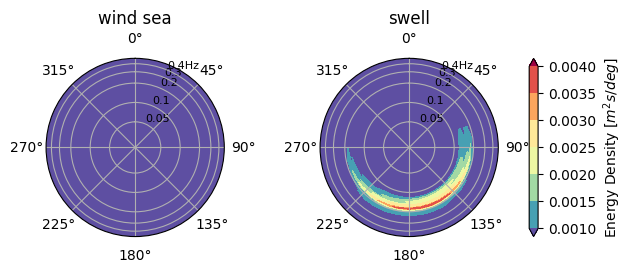

In [92]:
g = dspart.spec.plot(col="part", normalised=False, cmap="Spectral_r", extend='both')

for i, ax in enumerate(g.axes.flat):
    if i < len(dspart.part):
        label = dspart.label.values[i]
        ax.set_title(label)

In [61]:
ds

<xarray.Dataset> Size: 105MB
Dimensions:    (time: 7776, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 62kB 2017-01-01 ... 2017-12-31T23:00:00
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 105MB 0.0 0.0 ... 0.0001682 0.0001788
    wspd       (time) float64 62kB 7.9 7.1 7.4 5.4 4.2 ... 11.3 11.3 10.8 10.4
    wdir       (time) float64 62kB 274.0 258.0 270.0 262.0 ... 25.0 20.0 16.0
    dpt        (time) float32 31kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [63]:

ds_subset = ds.coarsen(time=3, boundary='trim').mean()

In [64]:
ds_subset

<xarray.Dataset> Size: 35MB
Dimensions:    (time: 2592, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 21kB 2017-01-01T01:00:00 ... 2017-12-31T...
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 35MB 0.0 0.0 ... 0.0001107 0.0001178
    wspd       (time) float64 21kB 7.467 4.867 5.133 5.7 ... 10.77 11.73 10.83
    wdir       (time) float64 21kB 267.3 247.0 224.3 296.0 ... 23.33 19.0 20.33
    dpt        (time) float32 10kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [101]:
ds2 = ds_subset

col_wrap = 4
n_rows = 2592 // col_wrap
figsize = (15, 3 * n_rows)

ds2.spec.plot(
    normalised=False,
    col="time",
    figsize=figsize,
    cmap="Spectral_r",
    add_colorbar=False,
    col_wrap=col_wrap, 
    col_labels=False
)


Error in callback <function _draw_all_if_interactive at 0x000001E0E675FC40> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



ValueError: Image size of 1500x194400 pixels is too large. It must be less than 2^16 in each direction.

ValueError: Image size of 1500x194400 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1500x194400 with 1134 Axes>

In [100]:
ds_subset

<xarray.Dataset> Size: 35MB
Dimensions:    (time: 2592, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 21kB 2017-01-01T01:00:00 ... 2017-12-31T...
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 35MB 0.0 0.0 ... 0.0001107 0.0001178
    wspd       (time) float64 21kB 7.467 4.867 5.133 5.7 ... 10.77 11.73 10.83
    wdir       (time) float64 21kB 267.3 247.0 224.3 296.0 ... 23.33 19.0 20.33
    dpt        (time) float32 10kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

---

In [43]:
ds_subset

<xarray.Dataset> Size: 35MB
Dimensions:    (time: 2592, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 21kB 2017-01-01T01:00:00 ... 2017-12-31T...
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 35MB 0.0 0.0 ... 0.0001107 0.0001178

In [32]:
import xarray as xr
import numpy as np

# Creamos Dataset cos espectros e os clusters
ds_freq = xr.Dataset(
    data_vars={
        "efth_freq": (("time", "freq"), windowed_data_no_direct),
        "cluster": ("time", df['cluster'].values),
    },
    coords={
        "time": df['time'].values,
        "freq": freq
    }
)


In [20]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os

In [41]:
output_dir = "cluster_gifs"
os.makedirs(output_dir, exist_ok=True)

unique_clusters = np.unique(ds_freq['cluster'].values)
unique_clusters = [0]

# Array de frecuencias
freq = ds_freq['freq'].values

for cluster_id in unique_clusters:
    # Filtramos o dataset para este cluster
    cluster_ds = ds_freq.sel(time=(ds_freq['cluster'] == 0))
    cluster_ds = cluster_ds.sel(time=slice('2017-07-01', '2017-08-31'))

    # Datos dos espectros dese cluster (numpy array)
    cluster_data = cluster_ds['efth_freq'].values  # shape: (n_times_cluster, n_freqs)
    n_frames = cluster_data.shape[0]

    # Preparar figura
    fig, ax = plt.subplots(figsize=(8, 5))
    line, = ax.plot([], [], color='blue', label="Espectro temporal")
    mean_line, = ax.plot([], [], color='red', linestyle='--', label="Media do cluster")

    ax.set_xlim(freq.min(), freq.max())
    max_val = np.maximum(cluster_data.max(), mean_spectrum.max())  # escolle o maior dos dous
    ax.set_ylim(0, max_val * 1.1)

    ax.set_xlabel("Frecuencia (Hz)")
    ax.set_ylabel("Enerxía")
    ax.set_title(f"Evolución temporal - Cluster {cluster_id}")
    ax.legend()

    def init():
        line.set_data([], [])
        mean_line.set_data([], [])
        return line, mean_line

    def update(frame):
        y = cluster_data[frame]
        line.set_data(freq, y)
        
        mean_up_to_now = cluster_data[:frame+1].mean(axis=0)
        mean_line.set_data(freq, mean_up_to_now)
        return line, mean_line

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=n_frames,
        init_func=init,
        blit=True,
        interval=150
    )

    gif_path = os.path.join(output_dir, f"cluster_{cluster_id}.gif")
    ani.save(gif_path, writer="pillow")
    plt.close(fig)

print(f"GIFs creados en: {output_dir}")

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


GIFs creados en: cluster_gifs


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import pandas as pd

# Creamos directorio de saída
output_dir = "cluster_cartesian_gif"
os.makedirs(output_dir, exist_ok=True)

# Selección de cluster 0 e datas de xullo a agosto de 2017
ds_filtered = ds_subset.sel(time=ds_subset.time[(ds_subset['cluster_label'] == 0) &
                                                (ds_subset['time'] >= np.datetime64('2017-07-01')) &
                                                (ds_subset['time'] <= np.datetime64('2017-08-31'))])

efth = ds_filtered['efth'].values         # (t, f, d)
freq = ds_filtered['freq'].values         # (f,)
dir_deg = ds_filtered['dir'].values       # (d,)
time_vals = ds_filtered['time'].values    # (t,)

# Convertimos a radianos e coordenadas cartesianas
theta_rad = np.deg2rad(dir_deg)
FREQ, THETA = np.meshgrid(freq, theta_rad, indexing='ij')  # shape: (f, d)
X = FREQ * np.cos(THETA)
Y = FREQ * np.sin(THETA)

# Creamos a figura
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)
cmap = plt.get_cmap('viridis')

# Datos iniciais
current_frame = efth[0, :, :]  # shape: (f, d)
# Inicializa mean_img con algo non todo cero, para ver se se debuxa
#mean_img = ax.pcolormesh(X, Y, current_frame * 0.5, shading='auto', cmap='Reds', alpha=0.5, zorder=2)

# A imaxe principal (o frame actual) → zorder maior para ir enriba
img = ax.pcolormesh(X, Y, current_frame, shading='auto', cmap='viridis', vmin=0, vmax=np.max(efth), zorder=3)


ax.set_aspect('equal')
ax.set_title("Evolución espectral - Cluster 0")
cb = plt.colorbar(img, ax=ax, label="Enerxía")

# Animación
def update(frame):
    current = efth[frame]
    img.set_array(current.ravel())

    # Media acumulada ata este punto
    mean_so_far = efth[:frame+1].mean(axis=0)
    #mean_img.set_array(mean_so_far.ravel())

    timestamp = pd.to_datetime(time_vals[frame]).strftime('%Y-%m-%d %H:%M')
    ax.set_title(f"Cluster 0 – {timestamp}")
    return img

ani = animation.FuncAnimation(
    fig, update, frames=len(efth), blit=False, interval=350
)

# Gardar animación
ani.save(os.path.join(output_dir, "cluster_0_cartesian.gif"), writer="pillow")
plt.close()
print(f"GIF gardado en: {output_dir}")


C:\Users\marco\AppData\Local\Temp\ipykernel_5252\3112681484.py:38: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


GIF gardado en: cluster_cartesian_gif
